# Notebook 15 (V4_3) — Pathwise Common-Growth AHP Calibration Audit

This notebook asks whether the model can reproduce the qualitative NFA decomposition in Atkeson, Heathcote, and Perri (AHP) while restoring common long-run growth at every absorbing switch-state BGP. The target is a large negative U.S. NFA movement generated primarily by revaluation of foreign-held U.S. equity claims, with a comparatively smooth quantity-flow current account (CA).

The workflow is deliberately sequential:

1. jointly recalibrate the RoW growth primitives `(a_W, ξ_W)` while keeping the literal U.S. bubble exponent `ν_b = 0.10` fixed;
2. verify the reference common-growth restriction and evaluate the full transition with exact AHP accounting;
3. activate the permitted `ν_b`-absorbing fallback only if every successful RoW-only calibration fails the pre-registered AHP mechanism checks;
4. search a small, auditable fallback catalog and report both successes and remaining gaps.

In the reported fallback, all structural calibration inputs remain time invariant and `common_world_growth=true`. The model first calibrates one global `ν_b` at the reference absorbing BGP. As in Notebook 12, each switch-state absorbing BGP then uses its own effective exponent `ν_b_eff` to impose `G_N,US^ν_b_eff = G_N,W^ξ_W` exactly along the entire extended path. The notebook reports the range of those effective exponents explicitly; it does not describe them as one literal fixed exponent.


In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not locate Project.toml from $(start_dir)")
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)
include(joinpath(PROJECT_DIR, "Two_country_production", "TwoCountryProductionOLG.jl"))

using DelimitedFiles
using Plots, Printf, Statistics, LinearAlgebra
using Plots.PlotMeasures

gr()

const DEFAULT_OUTDIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                                "ahp_pattern_common_growth_search")
const OUTDIR = get(ENV, "NB15_OUTDIR", DEFAULT_OUTDIR)
const BASELINE_DIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                              "hkt_increasing_q_large_bubble_share_common_growth")
mkpath(OUTDIR)

const RESID_TOL = 1e-5
const PSI_INTERIOR_TOL = 0.02
const EQUITY_INTERIOR_TOL = 0.01
const THETA_INTERIOR_TOL = 0.01
const ACCOUNTING_SCALED_TOL = 1e-7
const COMMON_GROWTH_TOL = 1e-7
const NU_ORDER_BUFFER = 1e-3
const AHP_ASSET_VA_ANCHOR_2010_2020 = 0.413
const AHP_LIABILITY_VA_ANCHOR_2010_2020 = -1.036
const AHP_NET_VA_ANCHOR_2010_2020 = -0.623

# NB15_SMOKE=1 is a developer-only plumbing check and is never used for reported results.
const SMOKE_MODE = get(ENV, "NB15_SMOKE", "0") == "1"
const STRICT_AUDIT_T = SMOKE_MODE ? 8 : 30
const FALLBACK_SEARCH_T = SMOKE_MODE ? 8 : 15
const FINAL_T = SMOKE_MODE ? 10 : 30
const AUDIT_BUFFER = SMOKE_MODE ? 4 : 10
const SEARCH_BUFFER = SMOKE_MODE ? 4 : 6
const FINAL_BUFFER = SMOKE_MODE ? 4 : 10
const FINALIST_COUNT = SMOKE_MODE ? 1 : 2

default(size=(950, 520), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=9mm, right_margin=7mm, top_margin=7mm, bottom_margin=8mm)

println("Julia version:              ", VERSION)
println("Project directory:          ", PROJECT_DIR)
println("Baseline directory:         ", BASELINE_DIR)
println("Output directory:           ", OUTDIR)
println("Execution mode:             ", SMOKE_MODE ? "SMOKE (not for reporting)" : "FULL")
println("Strict RoW-audit horizon:    ", STRICT_AUDIT_T)
println("Fallback search horizon:     ", FALLBACK_SEARCH_T)
println("Final reporting horizon:     ", FINAL_T)


  Activating 

Julia version:              1

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


.12.1
Project directory:          /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes
Baseline directory:         /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_increasing_q_large_bubble_share_common_growth
Output directory:           /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_common_growth_search
Execution mode:             FULL
Strict RoW-audit horizon:    30
Fallback search horizon:     15
Final reporting horizon:     30


## 1. Why Notebook 12's normalized cumulative CA rises and then falls

The saved Notebook 12 numerator is not reversing: raw cumulative CA is monotone increasing. The `_y` figure divides this historical cumulative sum by **current** U.S. output, while `combo_ahp_style_two_panel_components_e.png` divides it by **current** U.S. equity value `e_US` (not output). In the saved path, `Y_US` grows by roughly 500 times and `e_US` by roughly 535 times. Once either current denominator grows faster than cumulative CA, the displayed ratio must fall even though cumulative CA is still increasing.

This is a denominator effect, not a late reversal of the raw cumulative current account. The cell below verifies both normalizations directly from the baseline CSVs with DelimitedFiles only. The new calibration retains current-Y-normalized paths for direct comparison, but scores late-window movements using one fixed endpoint denominator, `Y_US,T`. The latter keeps the exact accounting identity visible without a moving denominator manufacturing a hump.


In [2]:
function read_numeric_csv(path::AbstractString)
    isfile(path) || error("Required baseline CSV not found: $(path)")
    data, header = readdlm(path, ',', Float64, '\n'; header=true)
    data_matrix = ndims(data) == 1 ? reshape(data, 1, :) : data
    names = String.(vec(header))
    size(data_matrix, 2) == length(names) ||
        error("Header/data column mismatch in $(path)")
    return Dict(names[j] => Float64.(data_matrix[:, j]) for j in eachindex(names))
end

function require_columns(table, names, label)
    missing_names = filter(name -> !haskey(table, name), names)
    isempty(missing_names) ||
        error("Missing columns in $(label): $(join(missing_names, ", "))")
end

baseline_ahp = read_numeric_csv(joinpath(BASELINE_DIR, "combo_ahp_style_decomposition.csv"))
baseline_cumulative = read_numeric_csv(joinpath(BASELINE_DIR, "combo_ahp_cumulative_va_ca_subcomponents_y.csv"))
baseline_paths = read_numeric_csv(joinpath(BASELINE_DIR, "combo_all_u_endogenous_paths.csv"))

require_columns(baseline_ahp, ["t", "cum_CA", "Y_US", "e_US"], "baseline AHP accounting")
require_columns(baseline_cumulative, ["t", "cum_CA_total_Y", "Y_US"], "baseline cumulative subcomponents")
require_columns(baseline_paths, ["t", "Y_US"], "baseline endogenous paths")

base_cum_CA = baseline_ahp["cum_CA"]
base_Y = baseline_ahp["Y_US"]
base_e = baseline_ahp["e_US"]
base_cum_CA_over_current_Y = base_cum_CA ./ base_Y
base_cum_CA_over_current_e = base_cum_CA ./ base_e
base_scale = max(1.0, maximum(abs.(base_cum_CA)))
base_raw_monotone = all(diff(base_cum_CA) .>= -1e-12 * base_scale)
base_Y_growth = base_Y[end] / base_Y[1]
base_e_growth = base_e[end] / base_e[1]
base_CA_peak_t = Int(round(baseline_ahp["t"][argmax(base_cum_CA_over_current_Y)]))
base_CA_e_peak_t = Int(round(baseline_ahp["t"][argmax(base_cum_CA_over_current_e)]))
base_CA_ratio_peak = maximum(base_cum_CA_over_current_Y)
base_CA_ratio_final = base_cum_CA_over_current_Y[end]
base_CA_backtracking = max(0.0, base_CA_ratio_peak - base_CA_ratio_final)
base_CA_e_ratio_peak = maximum(base_cum_CA_over_current_e)
base_CA_e_ratio_final = base_cum_CA_over_current_e[end]
base_CA_e_backtracking = max(0.0, base_CA_e_ratio_peak - base_CA_e_ratio_final)
base_ratio_csv_error = maximum(abs.(base_cum_CA_over_current_Y .-
                                    baseline_cumulative["cum_CA_total_Y"]))
base_Y_csv_error = maximum(abs.(base_Y .- baseline_paths["Y_US"]))

diagnosis_rows = Dict{String,Any}[
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"raw_cum_CA_monotone",
         "value"=>base_raw_monotone,
         "interpretation"=>"Raw cumulative CA never reverses within numerical tolerance."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"raw_cum_CA_final",
         "value"=>base_cum_CA[end],
         "interpretation"=>"The numerator continues to rise through the endpoint."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"Y_US_growth_T_over_1",
         "value"=>base_Y_growth,
         "interpretation"=>"Current U.S. output is the rapidly expanding denominator."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_Y_peak",
         "value"=>base_CA_ratio_peak,
         "interpretation"=>"Peak of the moving-denominator ratio."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_Y_final",
         "value"=>base_CA_ratio_final,
         "interpretation"=>"Endpoint after output growth outruns cumulative CA."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_ratio_backtracking",
         "value"=>base_CA_backtracking,
         "interpretation"=>"Peak minus endpoint; denominator-driven because raw cum CA is monotone."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"e_US_growth_T_over_1",
         "value"=>base_e_growth,
         "interpretation"=>"Current U.S. equity value is the denominator in the `_e` figure."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_e_peak",
         "value"=>base_CA_e_ratio_peak,
         "interpretation"=>"Peak of cumulative CA divided by current e_US."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_e_final",
         "value"=>base_CA_e_ratio_final,
         "interpretation"=>"Endpoint after e_US growth outruns cumulative CA."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_e_backtracking",
         "value"=>base_CA_e_backtracking,
         "interpretation"=>"Peak minus endpoint in the `_e` figure; also denominator-driven."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_ratio_cross_csv_error",
         "value"=>base_ratio_csv_error,
         "interpretation"=>"Agreement between the two saved Notebook 12 accounting CSVs."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"Y_US_cross_csv_error",
         "value"=>base_Y_csv_error,
         "interpretation"=>"Agreement with the saved all-u endogenous-path CSV.")
]

@printf("\nNotebook 12 denominator diagnosis\n")
@printf("  raw cumulative CA monotone: %s\n", base_raw_monotone)
@printf("  raw cumulative CA:          %.6g -> %.6g\n", base_cum_CA[1], base_cum_CA[end])
@printf("  Y_US growth:                %.3fx\n", base_Y_growth)
@printf("  cum CA/current Y peak:      %.6f at t=%d\n", base_CA_ratio_peak, base_CA_peak_t)
@printf("  cum CA/current Y endpoint:  %.6f\n", base_CA_ratio_final)
@printf("  Y denominator backtracking: %.6f\n", base_CA_backtracking)
@printf("  e_US growth:                 %.3fx\n", base_e_growth)
@printf("  cum CA/current e peak:       %.6f at t=%d\n", base_CA_e_ratio_peak, base_CA_e_peak_t)
@printf("  cum CA/current e endpoint:   %.6f\n", base_CA_e_ratio_final)
@printf("  e denominator backtracking: %.6f\n\n", base_CA_e_backtracking)

base_raw_monotone || error("Saved baseline no longer supports the monotone-raw-CA diagnosis.")
base_Y_growth > 100 || @warn "Baseline Y growth is much smaller than the documented roughly 500x path." base_Y_growth
base_e_growth > 100 || @warn "Baseline e_US growth is much smaller than the documented roughly 535x path." base_e_growth



Notebook 12 denominator diagnosis
  raw cumulative CA monotone: true
  raw cumulative CA:          0 -> 49.6344
  Y_US growth:                499.887x
  cum CA/current Y peak:      0.114148 at t=25
  cum CA/current Y endpoint:  0.057247
  Y denominator backtracking: 0.056901
  e_US growth:                 534.926x
  cum CA/current e peak:       0.114521 at t=24
  cum CA/current e endpoint:   0.055216
  e denominator backtracking: 0.059304



true

## 2. Exact AHP accounting and two normalizations

For U.S. holdings of RoW equity n_W, foreign holdings of U.S. equity n_US_star, and the U.S. bond position b,

NFA_t = q_W,t n_W,t + b_t - q_US,t n_US_star,t.

For each transition, the product rule is exact in discrete time when quantity changes use current prices and price changes use lagged quantities:

VA_t = n_W,t-1 Delta q_W,t - n_US_star,t-1 Delta q_US,t

CA_t = q_W,t Delta n_W,t - q_US,t Delta n_US_star,t + Delta b_t.

The implementation also retains every asset, liability, and bond subcomponent. It reports four distinct objects without conflating them:

1. the primary AHP normalization: cumulate nominal flows first, then divide each cumulative stock/flow by current Y_US,t;
2. the actual level ratio NFA_t / Y_US,t, whose deterioration is required for an economic pattern pass;
3. period-normalized cumulative flows, cumsum(flow_t / Y_US,t), retained only as a clearly labelled secondary diagnostic;
4. late-window endpoint normalization: all nominal changes since the late-window start divided by the single Y_US,T, used to isolate the revaluation mechanism.

The score prioritizes the AHP/current-output NFA ratio direction and uses the fixed-endpoint decomposition only as a mechanism diagnostic. The 2010–2020 anchors asset +0.413, liability -1.036, and net -0.623 are reference distances only, not exact calibration targets.


In [3]:
path_vector(result, field::Symbol) = Float64[getfield(s, field) for s in result.u_path]

# Pre-registered AHP comparison window: the second half of every solved path.
late_start_index(T::Int) = max(1, fld(T, 2))

function cumulative_since(x::AbstractVector, start::Int)
    out = zeros(Float64, length(x))
    for t in (start + 1):length(x)
        out[t] = out[t - 1] + x[t]
    end
    return out
end

turnover_reversal(x::AbstractVector) =
    0.5 * max(0.0, sum(abs, x) - abs(sum(x)))

function ahp_accounting(result::ProductionSimulationResult)
    T = length(result.u_path)
    T >= 3 || error("AHP accounting needs at least three periods.")

    q_US = path_vector(result, :q_US)
    q_W = path_vector(result, :q_W)
    Y_US = path_vector(result, :Y_US)
    e_US = path_vector(result, :e_US)

    n_W = Float64[(1 - s.ω) * (1 - s.θ) * s.A / s.q_W for s in result.u_path]
    n_US_star = Float64[s.ω_star * (1 - s.θ_US_star) * s.A_star / s.q_US
                        for s in result.u_path]
    bond = Float64[s.θ * s.A for s in result.u_path]

    asset_position = q_W .* n_W
    liability_position = q_US .* n_US_star
    NFA = asset_position .+ bond .- liability_position

    VA_asset = zeros(T)
    VA_liability = zeros(T)
    CA_asset = zeros(T)
    CA_liability = zeros(T)
    CA_bond = zeros(T)

    for t in 2:T
        VA_asset[t] = n_W[t - 1] * (q_W[t] - q_W[t - 1])
        VA_liability[t] = -n_US_star[t - 1] * (q_US[t] - q_US[t - 1])
        CA_asset[t] = q_W[t] * (n_W[t] - n_W[t - 1])
        CA_liability[t] = -q_US[t] * (n_US_star[t] - n_US_star[t - 1])
        CA_bond[t] = bond[t] - bond[t - 1]
    end

    VA = VA_asset .+ VA_liability
    CA = CA_asset .+ CA_liability .+ CA_bond
    ΔNFA = zeros(T)
    RES = zeros(T)
    for t in 2:T
        ΔNFA[t] = NFA[t] - NFA[t - 1]
        RES[t] = ΔNFA[t] - CA[t] - VA[t]
    end

    cum_VA_asset = cumsum(VA_asset)
    cum_VA_liability = cumsum(VA_liability)
    cum_CA_asset = cumsum(CA_asset)
    cum_CA_liability = cumsum(CA_liability)
    cum_CA_bond = cumsum(CA_bond)
    cum_VA = cumsum(VA)
    cum_CA = cumsum(CA)
    cum_RES = cumsum(RES)
    accounting_line = NFA[1] .+ cum_CA .+ cum_VA .+ cum_RES

    # Period-normalized flows are a secondary diagnostic, not the AHP figure.
    # AHP cumulates nominal flows first and divides the cumulative sum by current Y.
    ΔNFA_current_Y = ΔNFA ./ Y_US
    CA_current_Y = CA ./ Y_US
    VA_current_Y = VA ./ Y_US
    RES_current_Y = RES ./ Y_US
    VA_asset_current_Y = VA_asset ./ Y_US
    VA_liability_current_Y = VA_liability ./ Y_US
    CA_asset_current_Y = CA_asset ./ Y_US
    CA_liability_current_Y = CA_liability ./ Y_US
    CA_bond_current_Y = CA_bond ./ Y_US
    periodnorm_cum_ΔNFA = cumsum(ΔNFA_current_Y)
    periodnorm_cum_CA = cumsum(CA_current_Y)
    periodnorm_cum_VA = cumsum(VA_current_Y)
    periodnorm_cum_RES = cumsum(RES_current_Y)

    late_start = late_start_index(T)
    late_cum_VA_asset = cumulative_since(VA_asset, late_start)
    late_cum_VA_liability = cumulative_since(VA_liability, late_start)
    late_cum_CA_asset = cumulative_since(CA_asset, late_start)
    late_cum_CA_liability = cumulative_since(CA_liability, late_start)
    late_cum_CA_bond = cumulative_since(CA_bond, late_start)
    late_cum_VA = cumulative_since(VA, late_start)
    late_cum_CA = cumulative_since(CA, late_start)
    late_cum_RES = cumulative_since(RES, late_start)
    late_accounting_line = NFA[late_start] .+ late_cum_CA .+ late_cum_VA .+ late_cum_RES

    module_NFA = nfa_decomposition(result).NFA
    return (T=T, q_US=q_US, q_W=q_W, Y_US=Y_US, e_US=e_US,
            n_W=n_W, n_US_star=n_US_star, bond=bond,
            asset_position=asset_position, liability_position=liability_position,
            NFA=NFA, ΔNFA=ΔNFA, module_NFA=module_NFA,
            VA_asset=VA_asset, VA_liability=VA_liability, VA=VA,
            CA_asset=CA_asset, CA_liability=CA_liability, CA_bond=CA_bond, CA=CA,
            RES=RES,
            cum_VA_asset=cum_VA_asset, cum_VA_liability=cum_VA_liability,
            cum_CA_asset=cum_CA_asset, cum_CA_liability=cum_CA_liability,
            cum_CA_bond=cum_CA_bond, cum_VA=cum_VA, cum_CA=cum_CA,
            cum_RES=cum_RES, accounting_line=accounting_line,
            ΔNFA_current_Y=ΔNFA_current_Y, CA_current_Y=CA_current_Y,
            VA_current_Y=VA_current_Y, RES_current_Y=RES_current_Y,
            VA_asset_current_Y=VA_asset_current_Y,
            VA_liability_current_Y=VA_liability_current_Y,
            CA_asset_current_Y=CA_asset_current_Y,
            CA_liability_current_Y=CA_liability_current_Y,
            CA_bond_current_Y=CA_bond_current_Y,
            periodnorm_cum_ΔNFA=periodnorm_cum_ΔNFA,
            periodnorm_cum_CA=periodnorm_cum_CA,
            periodnorm_cum_VA=periodnorm_cum_VA,
            periodnorm_cum_RES=periodnorm_cum_RES,
            late_start=late_start,
            late_cum_VA_asset=late_cum_VA_asset,
            late_cum_VA_liability=late_cum_VA_liability,
            late_cum_CA_asset=late_cum_CA_asset,
            late_cum_CA_liability=late_cum_CA_liability,
            late_cum_CA_bond=late_cum_CA_bond,
            late_cum_VA=late_cum_VA, late_cum_CA=late_cum_CA,
            late_cum_RES=late_cum_RES,
            late_accounting_line=late_accounting_line,
            residual_max=maximum(abs.(RES[2:end])),
            nfa_identity_error=maximum(abs.(NFA .- module_NFA)))
end

function candidate_metrics(a)
    Y = a.Y_US
    i0 = a.late_start
    late = (i0 + 1):a.T
    ahp_cum_CA_current_Y = a.cum_CA ./ Y
    ca_backtracking = turnover_reversal(a.CA_current_Y[2:end])
    late_ca_backtracking = turnover_reversal(a.CA_current_Y[late])
    moving_denominator_backtracking = turnover_reversal(diff(ahp_cum_CA_current_Y))
    ca_tv_excess = 2.0 * ca_backtracking

    late_nfa_move = (a.NFA[end] - a.NFA[i0]) / Y[end]
    late_periodnorm_nfa_sum = sum(a.ΔNFA_current_Y[late])
    late_ratio_change = a.NFA[end] / Y[end] - a.NFA[i0] / Y[i0]
    late_va_asset = a.late_cum_VA_asset[end] / Y[end]
    late_va_liability = a.late_cum_VA_liability[end] / Y[end]
    late_va_net = a.late_cum_VA[end] / Y[end]
    late_ca = a.late_cum_CA[end] / Y[end]
    late_residual = a.late_cum_RES[end] / Y[end]
    liability_dominance = abs(late_va_liability) / max(abs(late_va_asset), 1e-8)
    liability_dominance_share = abs(late_va_liability) /
        max(abs(late_va_asset) + abs(late_va_liability), 1e-8)
    late_foreign_exposure = mean(a.liability_position[late] ./ Y[late])
    late_asset_exposure = mean(a.asset_position[late] ./ Y[late])
    ca_flow_rms = sqrt(mean((a.CA[late] ./ Y[late]).^2))
    ca_roughness = std(a.CA_current_Y[late]; corrected=false)
    va_driver_share = abs(late_va_net) /
        max(abs(late_va_net) + abs(late_ca), 1e-8)
    ca_share = abs(late_ca) / max(abs(late_va_net) + abs(late_ca), 1e-8)
    whole_path_nfa_move = (a.NFA[end] - a.NFA[1]) / Y[end]
    full_ratio_change = a.NFA[end] / Y[end] - a.NFA[1] / Y[1]
    full_path_match = whole_path_nfa_move <= -0.05 && full_ratio_change <= -0.05
    nfa_initial_current_Y = a.NFA[1] / Y[1]
    nfa_final_current_Y = a.NFA[end] / Y[end]
    anchor_distance = sqrt(
        (late_va_asset - AHP_ASSET_VA_ANCHOR_2010_2020)^2 +
        (late_va_liability - AHP_LIABILITY_VA_ANCHOR_2010_2020)^2 +
        (late_va_net - AHP_NET_VA_ANCHOR_2010_2020)^2
    )

    return (late_start=i0,
            late_nfa_move=late_nfa_move,
            late_periodnorm_nfa_sum=late_periodnorm_nfa_sum,
            late_ratio_change=late_ratio_change,
            late_va_asset=late_va_asset,
            late_va_liability=late_va_liability,
            late_va_net=late_va_net,
            late_ca=late_ca,
            late_residual=late_residual,
            liability_dominance=liability_dominance,
            liability_dominance_share=liability_dominance_share,
            late_foreign_exposure=late_foreign_exposure,
            late_asset_exposure=late_asset_exposure,
            ca_backtracking=ca_backtracking,
            late_ca_backtracking=late_ca_backtracking,
            moving_denominator_backtracking=moving_denominator_backtracking,
            ca_tv_excess=ca_tv_excess,
            ca_flow_rms=ca_flow_rms,
            ca_roughness=ca_roughness,
            va_driver_share=va_driver_share,
            ca_share=ca_share,
            whole_path_nfa_move=whole_path_nfa_move,
            full_ratio_change=full_ratio_change,
            full_path_match=full_path_match,
            nfa_initial_current_Y=nfa_initial_current_Y,
            nfa_final_current_Y=nfa_final_current_Y,
            anchor_distance=anchor_distance,
            Y_growth=Y[end] / Y[1],
            q_US_growth=a.q_US[end] / a.q_US[1],
            q_W_growth=a.q_W[end] / a.q_W[1])
end

function hard_validity(result, a)
    theta_US_star = path_vector(result, :θ_US_star)
    finite_accounting = all(isfinite, a.NFA) && all(isfinite, a.CA) &&
                        all(isfinite, a.VA) && all(isfinite, a.Y_US)
    model_residuals = result.branch_converged &&
                      isfinite(result.max_u_residual) &&
                      isfinite(result.max_bgp_residual) &&
                      result.max_u_residual <= RESID_TOL &&
                      result.max_bgp_residual <= RESID_TOL
    psi_interior = result.diagnostics.psi_ok &&
                   isfinite(result.diagnostics.psi_min) &&
                   result.diagnostics.psi_min >= PSI_INTERIOR_TOL
    equity_interior = result.diagnostics.equity_weights_ok &&
                      isfinite(result.diagnostics.equity_weight_min) &&
                      result.diagnostics.equity_weight_min >= EQUITY_INTERIOR_TOL
    theta_interior = all(x -> isfinite(x) && THETA_INTERIOR_TOL <= x < 0.9,
                         theta_US_star)
    positive_foreign_claims = all(x -> isfinite(x) && x > 0.0, a.n_US_star) &&
                              all(x -> isfinite(x) && x > 0.0, a.liability_position)
    accounting_scale = max(1.0, maximum(abs.(a.NFA)), maximum(abs.(a.CA)),
                           maximum(abs.(a.VA)))
    accounting_exact = isfinite(a.residual_max) && a.residual_max <= RESID_TOL &&
                       a.residual_max / accounting_scale <= ACCOUNTING_SCALED_TOL &&
                       isfinite(a.nfa_identity_error) &&
                       a.nfa_identity_error / accounting_scale <= ACCOUNTING_SCALED_TOL
    return_fields = (:R_A_u, :R_A_b, :R_A_star_u, :R_A_star_b, :R_f, :R_f_W)
    positive_returns = all(field -> all(x -> isfinite(x) && x > 0.0,
                                            path_vector(result, field)), return_fields)
    positive_output = all(x -> isfinite(x) && x > 0.0, a.Y_US)

    valid = model_residuals && psi_interior && equity_interior &&
            theta_interior && positive_foreign_claims && positive_returns && accounting_exact &&
            positive_output && finite_accounting
    return (valid=valid, model_residuals=model_residuals,
            psi_interior=psi_interior, equity_interior=equity_interior,
            theta_interior=theta_interior,
            positive_foreign_claims=positive_foreign_claims,
            positive_returns=positive_returns,
            accounting_exact=accounting_exact,
            positive_output=positive_output,
            finite_accounting=finite_accounting)
end

# Lower is better. Directional failures receive much larger weights than
# the AHP level-distance anchor, so the score remains a qualitative pattern score.
function economic_classification(m)
    strong = m.late_nfa_move <= -0.02 && m.late_ratio_change <= -0.02 &&
             m.full_ratio_change <= -0.02 && m.late_va_liability <= -0.04 &&
             m.late_va_net <= -0.03 && m.late_foreign_exposure >= 0.30 &&
             m.va_driver_share >= 0.60 && m.liability_dominance_share >= 0.70 &&
             m.ca_share <= 0.50 && m.moving_denominator_backtracking <= 0.10 &&
             m.ca_roughness <= 0.02
    partial = m.whole_path_nfa_move < 0.0 && m.full_ratio_change < 0.0 &&
              m.late_va_liability < 0.0 && m.late_va_net < 0.0 &&
              m.liability_dominance_share > 0.50 &&
              m.va_driver_share > 0.50 && m.late_foreign_exposure > 0.10
    mechanism_near_miss = m.late_nfa_move < 0.0 &&
                          m.late_va_liability < 0.0 && m.late_va_net < 0.0 &&
                          m.liability_dominance_share > 0.50 &&
                          m.va_driver_share > 0.50 && m.late_foreign_exposure > 0.10
    return strong ? "strong_pattern" :
           partial ? "partial_ahp_pattern" :
           mechanism_near_miss ? "liability_revaluation_near_miss" : "near_miss"
end

function relaxed_ahp_score(m)
    nfa_direction_penalty = max(0.0, m.late_nfa_move + 0.10)
    periodnorm_penalty = max(0.0, m.late_periodnorm_nfa_sum + 0.02)
    ratio_change_penalty = max(0.0, m.late_ratio_change + 0.02)
    full_ratio_change_penalty = max(0.0, m.full_ratio_change + 0.02)
    liability_direction_penalty = max(0.0, m.late_va_liability + 0.10)
    net_va_direction_penalty = max(0.0, m.late_va_net + 0.05)
    dominance_penalty = max(0.0, 0.70 - m.liability_dominance_share)
    va_driver_penalty = max(0.0, 0.60 - m.va_driver_share)
    ca_share_penalty = max(0.0, m.ca_share - 0.50)
    exposure_penalty = max(0.0, 0.20 - m.late_foreign_exposure)
    whole_path_penalty = max(0.0, m.whole_path_nfa_move)

    return 10.0 * nfa_direction_penalty +
            0.5 * periodnorm_penalty +
           20.0 * ratio_change_penalty +
           12.0 * full_ratio_change_penalty +
           10.0 * liability_direction_penalty +
            4.0 * net_va_direction_penalty +
            1.5 * dominance_penalty +
            1.5 * va_driver_penalty +
            1.0 * ca_share_penalty +
            5.0 * abs(m.late_ca) +
            1.0 * m.ca_backtracking +
            4.0 * m.late_ca_backtracking +
            1.0 * m.moving_denominator_backtracking +
            1.0 * m.ca_flow_rms +
            2.0 * exposure_penalty +
            0.25 * whole_path_penalty +
            0.10 * abs(m.nfa_initial_current_Y) +
            0.15 * m.anchor_distance
end


relaxed_ahp_score (generic function with 1 method)

## 3. Sequential calibration design

### Stage A — literal fixed-`ν_b` RoW recalibration

For every pre-registered value of `ξ_W`, the notebook solves for `a_W` so that the initial absorbing BGP satisfies

`ν_b log(G_N,US) = ξ_W log(G_N,W)`, with `ν_b = 0.10`.

This is a joint calibration of the two RoW growth primitives: `ξ_W` is searched across economically distinct values and `a_W` is solved endogenously conditional on it. The full transition is then simulated with `common_world_growth=false`, so `ν_b` remains literally fixed. Matching the initial BGP is not confused with matching every switch-state BGP; both reference and maximum path gaps are reported.

### Stage B — permitted pathwise fallback, conditional on confirmed Stage-A failure

The fallback block is guarded by an assertion: it cannot run unless all five hard-valid Stage-A calibrations fail the pre-registered AHP mechanism check. This is a bounded confirmation within the audited `(ξ_W,a_W)` family, not a theorem that every possible RoW calibration fails.

The fallback sets `common_world_growth=true`. It calibrates the global `ν_b` at the reference BGP and then, exactly as in Notebook 12, solves every absorbing switch-state BGP with a state-specific `ν_b_eff`. The hard gates require every BGP in `bgp_seq_extended` to converge below the residual tolerance, the maximum level and log common-growth errors to be no larger than `1e-7`, and every effective exponent to stay positive and below `ν_u`. The AHP score continues to emphasize stable RoW equity prices, near-zero asset revaluation, negative and dominant U.S. liability revaluation, small CA, and large foreign exposure. NFA direction remains an explicit reporting criterion.


In [4]:
Base.@kwdef struct StrictRoWSpec
    label::String
    ξ_W::Float64
    a_W_seed::Float64
end

Base.@kwdef struct FallbackSpec
    label::String
    note::String
    a_W::Float64
    ξ_W::Float64
    β::Float64 = 0.35
    κ::Float64 = 0.75
    ωbar::Float64 = 0.50
    ωbar_star::Float64 = 0.25
    χ::Float64 = 0.0002
    η::Float64 = 0.010
    ϑ_US::Float64 = 0.80
    ξ_u::Float64 = 1.90
    ν_u::Float64 = 1.895
    H_W::Float64 = 3.0
    L_W::Float64 = 3.0
    ν_b_seed::Float64 = 0.10
    us_u_level::Float64 = 1.0
end

const STRICT_ROW_SPECS = StrictRoWSpec[
    StrictRoWSpec(label="row_xi005", ξ_W=0.05, a_W_seed=0.0728521),
    StrictRoWSpec(label="row_xi010", ξ_W=0.10, a_W_seed=0.0545516),
    StrictRoWSpec(label="row_xi030", ξ_W=0.30, a_W_seed=0.0428390),
    StrictRoWSpec(label="row_xi050", ξ_W=0.50, a_W_seed=0.0404469),
    StrictRoWSpec(label="row_xi100", ξ_W=1.00, a_W_seed=0.0386244),
]

# A small mechanism-directed catalog. The last two cases stabilize q_W and
# isolate foreign-held U.S. equity liability revaluation most cleanly.
const FALLBACK_SPECS = FallbackSpec[
    FallbackSpec(label="cg_xi050_reference", a_W=0.050, ξ_W=0.50,
        β=0.45, κ=1.00, ξ_u=1.90, ν_u=1.40,
        note="Moderate mismatch; original financial block."),
    FallbackSpec(label="cg_xi050_exposure", a_W=0.060, ξ_W=0.50,
        β=0.45, κ=1.00, ξ_u=1.90, ν_u=1.40,
        note="Larger RoW growth primitive with original financial block."),
    FallbackSpec(label="cg_xi050_low_beta", a_W=0.060, ξ_W=0.50,
        β=0.35, κ=0.75, ξ_u=1.90, ν_u=1.85,
        note="Near-flat NFA level path, but q_W and asset VA move the wrong way."),
    FallbackSpec(label="cg_xi100_stable_qw", a_W=0.050, ξ_W=1.00,
        β=0.35, κ=0.75, ξ_u=1.90, ν_u=1.85,
        note="Stable q_W and clean liability-side price revaluation."),
    FallbackSpec(label="cg_xi100_stable_qw_ceiling", a_W=0.050, ξ_W=1.00,
        β=0.35, κ=0.75, ξ_u=1.90, ν_u=1.895,
        note="Raises the unbalanced-growth ceiling while preserving exact pathwise common growth."),
    FallbackSpec(label="cg_us_u_level_110", a_W=0.050, ξ_W=1.00,
        β=0.35, κ=0.75, ξ_u=1.90, ν_u=1.895, us_u_level=1.10,
        note="Ten-percent U.S. unbalanced-regime level shift generates liability-led NFA deterioration."),
    FallbackSpec(label="cg_us_u_level_111", a_W=0.050, ξ_W=1.00,
        β=0.35, κ=0.75, ξ_u=1.90, ν_u=1.895, us_u_level=1.11,
        note="Eleven-percent level shift produces the strongest pattern among the reported candidates."),
]

function strict_params(spec::StrictRoWSpec, a_W::Float64; T::Int, n_buffer::Int)
    ProductionParams(
        T_max=T, n_buffer=n_buffer, common_world_growth=false,
        β=0.45, γ=0.25, π_persist=0.80,
        a_US=0.20, ϑ_US=0.80,
        a_W=a_W, H_W=3.0, L_W=3.0,
        ν_b=0.10, ν_u=1.40, ξ_u=1.90, ξ_W=spec.ξ_W,
        ω̄=0.50, ω̄_star=0.25,
        κ=1.00, χ=0.0002, η=0.010,
        branch_iters=60, do_global_polish=false,
    )
end

function fallback_params(spec::FallbackSpec; T::Int, n_buffer::Int)
    ProductionParams(
        T_max=T, n_buffer=n_buffer, common_world_growth=true,
        β=spec.β, γ=0.25, π_persist=0.80,
        a_US=0.20, ϑ_US=spec.ϑ_US,
        a_W=spec.a_W, H_W=spec.H_W, L_W=spec.L_W,
        A_X_US_u=10.0 * spec.us_u_level, A_L_US_u=1.0 * spec.us_u_level,
        ν_b=spec.ν_b_seed, ν_u=spec.ν_u, ξ_u=spec.ξ_u, ξ_W=spec.ξ_W,
        ω̄=spec.ωbar, ω̄_star=spec.ωbar_star,
        κ=spec.κ, χ=spec.χ, η=spec.η,
        branch_iters=60, do_global_polish=false,
    )
end

literal_common_log_gap(p, b) = p.ν_b * log(b.G_N_US) - p.ξ_W * log(b.G_N_W)

function calibrate_row_aW(spec::StrictRoWSpec; T::Int, n_buffer::Int)
    # A scalar secant solve repeatedly resolves the endogenous BGP, so the
    # common-growth restriction is imposed on equilibrium φ_US and φ_W rather
    # than on an exogenous approximation.
    function gap_at(a_W)
        p = strict_params(spec, a_W; T=max(6, min(T, 10)), n_buffer=4)
        b = solve_bgp_at(p, p.N_US_0, p.N_W_0)
        return literal_common_log_gap(p, b)
    end
    x0 = clamp(0.985 * spec.a_W_seed, 1e-5, 0.20)
    x1 = clamp(1.015 * spec.a_W_seed, 1e-5, 0.20)
    f0 = gap_at(x0)
    f1 = gap_at(x1)
    iterations = 2
    for iter in 3:14
        abs(f1) <= 1e-10 && break
        denominator = f1 - f0
        abs(denominator) > eps(Float64) || error("Degenerate RoW secant step for $(spec.label)")
        x2 = clamp(x1 - f1 * (x1 - x0) / denominator, 1e-5, 0.20)
        x0, f0 = x1, f1
        x1, f1 = x2, gap_at(x2)
        iterations = iter
    end
    a_W = x1
    p = strict_params(spec, a_W; T=T, n_buffer=n_buffer)
    b = solve_bgp_at(p, p.N_US_0, p.N_W_0)
    gap = literal_common_log_gap(p, b)
    abs(gap) <= COMMON_GROWTH_TOL ||
        error("RoW fixed point failed for $(spec.label): log gap=$(gap)")
    return (params=p, bgp=b, a_W=a_W, iterations=iterations, reference_log_gap=gap)
end

active_strict_specs = SMOKE_MODE ? STRICT_ROW_SPECS[1:2] : STRICT_ROW_SPECS
active_fallback_specs = SMOKE_MODE ? FALLBACK_SPECS[6:7] : FALLBACK_SPECS

# Diagnose why simply restoring common_world_growth on the old F calibration is
# infeasible: the implied exponent lies far above the old ν_u ceiling.
old_F_spec = StrictRoWSpec(label="old_F_common_growth_diagnostic", ξ_W=1.0, a_W_seed=0.10)
old_F_params = strict_params(old_F_spec, 0.10; T=6, n_buffer=4)
old_F_bgp = solve_bgp_at(old_F_params, old_F_params.N_US_0, old_F_params.N_W_0)
old_F_implied_nu_b = old_F_params.ξ_W * log(old_F_bgp.G_N_W) / log(old_F_bgp.G_N_US)

println("Strict RoW audit cases: ", length(active_strict_specs))
println("Conditional fallback cases: ", length(active_fallback_specs))
@printf("Old-F implied common-growth nu_b: %.6f (old nu_u ceiling %.3f)\n",
        old_F_implied_nu_b, old_F_params.ν_u)


Strict RoW audit cases: 5
Conditional fallback cases: 7
Old-F implied common-growth nu_b: 6.278680 (old nu_u ceiling 1.400)


In [5]:
function csv_cell(x)
    s = x === missing ? "" : string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function write_rows_csv(path, rows, columns)
    open(path, "w") do io
        println(io, join(columns, ','))
        for row in rows
            println(io, join((csv_cell(get(row, c, missing)) for c in columns), ','))
        end
    end
    return path
end

function common_growth_diagnostics(result)
    p = result.params
    rows = Dict{String,Any}[]
    for (j, b) in enumerate(result.bgp_seq_extended)
        G_b = b.G_N_US^b.ν_b_eff
        G_W = b.G_N_W^p.ξ_W
        push!(rows, Dict{String,Any}(
            "switch_index" => j - 1,
            "G_N_US" => b.G_N_US,
            "G_N_W" => b.G_N_W,
            "nu_b_eff" => b.ν_b_eff,
            "bgp_converged" => b.converged,
            "bgp_residual_norm" => b.residual_norm,
            "G_b" => G_b,
            "G_W" => G_W,
            "level_gap" => G_b - G_W,
            "log_gap" => b.ν_b_eff * log(b.G_N_US) - p.ξ_W * log(b.G_N_W),
        ))
    end
    return rows
end

function common_growth_summary(result)
    rows = common_growth_diagnostics(result)
    ν_b_eff = Float64[r["nu_b_eff"] for r in rows]
    return (
        max_level_gap=maximum(abs(Float64(r["level_gap"])) for r in rows),
        max_log_gap=maximum(abs(Float64(r["log_gap"])) for r in rows),
        nu_b_eff_min=minimum(ν_b_eff),
        nu_b_eff_max=maximum(ν_b_eff),
        nu_b_eff_std=std(ν_b_eff),
        all_extended_bgp_converged=all(Bool(r["bgp_converged"]) for r in rows),
        max_extended_bgp_residual=maximum(Float64(r["bgp_residual_norm"]) for r in rows),
    )
end

function literal_path_growth_summary(result)
    p = result.params
    gaps = Float64[p.ν_b * log(b.G_N_US) - p.ξ_W * log(b.G_N_W)
                   for b in result.bgp_seq_extended]
    return (initial=gaps[1], max_abs=maximum(abs, gaps), final=gaps[end])
end

function pathwise_common_validity(result, accounting)
    base = hard_validity(result, accounting)
    common = common_growth_summary(result)
    exact_common = common.max_level_gap <= COMMON_GROWTH_TOL &&
                   common.max_log_gap <= COMMON_GROWTH_TOL
    extended_bgp_valid = common.all_extended_bgp_converged &&
                         common.max_extended_bgp_residual <= RESID_TOL
    exponent_ordering = isfinite(common.nu_b_eff_min) &&
                        isfinite(common.nu_b_eff_max) &&
                        common.nu_b_eff_min > 0.0 &&
                        common.nu_b_eff_max <= result.params.ν_u - NU_ORDER_BUFFER
    return merge(base, (exact_common=exact_common,
                        extended_bgp_valid=extended_bgp_valid,
                        exponent_ordering=exponent_ordering,
                        common=common,
                        valid=base.valid && exact_common &&
                              extended_bgp_valid && exponent_ordering))
end

function strict_mechanism_pass(m)
    return m.full_ratio_change < 0.0 && m.whole_path_nfa_move < 0.0 &&
           m.late_va_asset >= 0.0 && m.late_va_liability < 0.0 &&
           m.late_va_net < 0.0 && abs(m.late_ca) < abs(m.late_va_net) &&
           m.q_US_growth > 1.0 && 0.90 <= m.q_W_growth <= 1.10
end

function evaluate_strict(spec::StrictRoWSpec)
    calibrated = calibrate_row_aW(spec; T=STRICT_AUDIT_T, n_buffer=AUDIT_BUFFER)
    result = run_production_simulation(calibrated.params; verbose=false)
    accounting = ahp_accounting(result)
    metrics = candidate_metrics(accounting)
    validity = hard_validity(result, accounting)
    path_growth = literal_path_growth_summary(result)
    pass = validity.valid && strict_mechanism_pass(metrics)
    row = Dict{String,Any}(
        "label" => spec.label, "status" => "ok", "xi_W" => spec.ξ_W,
        "a_W_seed" => spec.a_W_seed, "a_W_calibrated" => calibrated.a_W,
        "root_iterations" => calibrated.iterations,
        "nu_b_literal" => result.params.ν_b,
        "reference_log_gap" => calibrated.reference_log_gap,
        "max_literal_path_log_gap" => path_growth.max_abs,
        "hard_valid" => validity.valid, "ahp_mechanism_pass" => pass,
        "NFA_Y_initial" => metrics.nfa_initial_current_Y,
        "NFA_Y_final" => metrics.nfa_final_current_Y,
        "full_ratio_change" => metrics.full_ratio_change,
        "whole_path_nfa_move" => metrics.whole_path_nfa_move,
        "late_VA_asset" => metrics.late_va_asset,
        "late_VA_liability" => metrics.late_va_liability,
        "late_VA_net" => metrics.late_va_net, "late_CA" => metrics.late_ca,
        "foreign_exposure" => metrics.late_foreign_exposure,
        "q_US_growth" => metrics.q_US_growth, "q_W_growth" => metrics.q_W_growth,
        "max_u_residual" => result.max_u_residual,
        "max_bgp_residual" => result.max_bgp_residual,
        "failure_reason" => pass ? "" :
            "Initial common growth closes, but the transition fails at least one AHP mechanism criterion.",
    )
    return (spec=spec, calibrated=calibrated, result=result, accounting=accounting,
            metrics=metrics, validity=validity, row=row)
end

strict_records = Any[]
for spec in active_strict_specs
    @printf("Strict RoW audit: %-20s", spec.label)
    try
        record = evaluate_strict(spec)
        push!(strict_records, record)
        @printf("  a_W=%.8f  ref gap=%+.2e  ΔNFA/Y=%+.4f  VA_L=%+.4f  CA=%+.4f  pass=%s\n",
                record.calibrated.a_W, record.calibrated.reference_log_gap,
                record.metrics.full_ratio_change, record.metrics.late_va_liability,
                record.metrics.late_ca, record.row["ahp_mechanism_pass"])
    catch err
        push!(strict_records, (spec=spec, row=Dict{String,Any}(
            "label"=>spec.label, "status"=>"error", "xi_W"=>spec.ξ_W,
            "a_W_seed"=>spec.a_W_seed, "hard_valid"=>false,
            "ahp_mechanism_pass"=>false, "failure_reason"=>sprint(showerror, err))))
        @printf("  ERROR: %s\n", sprint(showerror, err))
    end
end

strict_successes = [r for r in strict_records if get(r.row, "status", "") == "ok"]
strict_all_solved = length(strict_successes) == length(active_strict_specs)
strict_all_hard_valid = strict_all_solved &&
                        all(Bool(r.row["hard_valid"]) for r in strict_successes)
strict_failure_confirmed = strict_all_hard_valid &&
                           all(!Bool(r.row["ahp_mechanism_pass"]) for r in strict_successes)

# This assertion enforces the user's sequencing instruction: ν_b is not allowed
# to absorb the mismatch until RoW-only recalibration has genuinely been tested.
strict_failure_confirmed || error(
    "The ν_b fallback is blocked: the bounded RoW audit did not solve every case, pass hard gates, and confirm economic failure.")

println("\nCONFIRMED WITHIN THE PRE-REGISTERED FAMILY: all five hard-valid RoW roots fail the AHP mechanism check.")
println("Activating the permitted pathwise state-specific effective-exponent fallback.\n")


Strict RoW audit: row_xi005             a_W=0.07285215  ref gap=+2.79e-11  ΔNFA/Y=+0.1811  VA_L=+0.0024  CA=+0.2742  pass=false
Strict RoW audit: row_xi010             a_W=0.05455162  ref gap=+6.24e-11  ΔNFA/Y=+0.1721  VA_L=+0.0029  CA=+0.1655  pass=false
Strict RoW audit: row_xi030             a_W=0.04283897  ref gap=-4.61e-15  ΔNFA/Y=+0.1685  VA_L=+0.0027  CA=+0.0935  pass=false
Strict RoW audit: row_xi050             a_W=0.04044687  ref gap=-1.45e-14  ΔNFA/Y=+0.1671  VA_L=+0.0023  CA=+0.0752  pass=false
Strict RoW audit: row_xi100             a_W=0.03862442  ref gap=-4.89e-14  ΔNFA/Y=+0.1636  VA_L=+0.0010  CA=+0.0535  pass=false

CONFIRMED WITHIN THE PRE-REGISTERED FAMILY: all five hard-valid RoW roots fail the AHP mechanism check.
Activating the permitted pathwise state-specific effective-exponent fallback.



In [6]:
function common_growth_classification(m)
    strong = m.full_ratio_change <= -0.02 && m.whole_path_nfa_move <= -0.02 &&
             m.late_va_asset > 0.0 && m.late_va_liability <= -0.04 &&
             m.late_va_net < 0.0 && abs(m.late_ca) < abs(m.late_va_net) &&
             m.late_foreign_exposure >= 0.20 && 0.90 <= m.q_W_growth <= 1.10
    partial = m.full_ratio_change < 0.0 && m.whole_path_nfa_move < 0.0 &&
              m.late_va_asset >= -0.002 && m.late_va_liability < 0.0 &&
              m.late_va_net < 0.0 && abs(m.late_ca) < abs(m.late_va_net) &&
              m.late_foreign_exposure >= 0.10 && 0.90 <= m.q_W_growth <= 1.10
    mechanism_near_miss = m.late_va_asset >= 0.0 && m.late_va_liability < 0.0 &&
                          m.late_va_net < 0.0 && abs(m.late_ca) <= 0.015 &&
                          m.late_foreign_exposure >= 0.10 &&
                          0.90 <= m.q_W_growth <= 1.10
    return strong ? "common_growth_ahp_pattern" :
           partial ? "common_growth_liability_revaluation_partial_pattern" :
           mechanism_near_miss ? "common_growth_liability_revaluation_near_miss" :
           "common_growth_near_miss"
end

function common_growth_score(m)
    # The extra terms encode the user's requested decomposition, not a level fit:
    # asset VA should be nonnegative, q_W should be stable, and CA should be smooth.
    return relaxed_ahp_score(m) +
           100.0 * max(0.0, -m.late_va_asset) +
            50.0 * abs(m.late_ca) +
            10.0 * abs(log(max(m.q_W_growth, 1e-8))) +
            10.0 * max(0.0, m.full_ratio_change) +
             5.0 * max(0.0, m.whole_path_nfa_move)
end

function fallback_row(spec, result, accounting, metrics, validity, score, horizon)
    return Dict{String,Any}(
        "label"=>spec.label, "note"=>spec.note, "status"=>"ok", "horizon"=>horizon,
        "hard_valid"=>validity.valid, "classification"=>common_growth_classification(metrics),
        "score"=>score, "a_W"=>spec.a_W, "xi_W"=>spec.ξ_W,
        "beta"=>spec.β, "kappa"=>spec.κ, "omega_bar"=>spec.ωbar,
        "omega_bar_star"=>spec.ωbar_star, "chi"=>spec.χ, "eta"=>spec.η,
        "vartheta_US"=>spec.ϑ_US, "xi_u"=>spec.ξ_u, "nu_u"=>spec.ν_u,
        "us_u_level"=>spec.us_u_level,
        "nu_b_seed"=>spec.ν_b_seed, "nu_b_calibrated"=>result.params.ν_b,
        "nu_b_eff_min"=>validity.common.nu_b_eff_min,
        "nu_b_eff_max"=>validity.common.nu_b_eff_max,
        "nu_b_eff_std"=>validity.common.nu_b_eff_std,
        "max_common_growth_level_gap"=>validity.common.max_level_gap,
        "max_common_growth_log_gap"=>validity.common.max_log_gap,
        "exact_common"=>validity.exact_common,
        "extended_bgp_valid"=>validity.extended_bgp_valid,
        "max_extended_bgp_residual"=>validity.common.max_extended_bgp_residual,
        "exponent_ordering"=>validity.exponent_ordering,
        "model_residuals"=>validity.model_residuals,
        "psi_interior"=>validity.psi_interior,
        "equity_interior"=>validity.equity_interior,
        "theta_interior"=>validity.theta_interior,
        "accounting_exact"=>validity.accounting_exact,
        "NFA_Y_initial"=>metrics.nfa_initial_current_Y,
        "NFA_Y_final"=>metrics.nfa_final_current_Y,
        "full_ratio_change"=>metrics.full_ratio_change,
        "whole_path_nfa_move"=>metrics.whole_path_nfa_move,
        "late_nfa_move"=>metrics.late_nfa_move,
        "late_VA_asset"=>metrics.late_va_asset,
        "late_VA_liability"=>metrics.late_va_liability,
        "late_VA_net"=>metrics.late_va_net, "late_CA"=>metrics.late_ca,
        "VA_driver_share"=>metrics.va_driver_share,
        "liability_dominance_share"=>metrics.liability_dominance_share,
        "foreign_exposure"=>metrics.late_foreign_exposure,
        "CA_flow_RMS"=>metrics.ca_flow_rms, "CA_roughness"=>metrics.ca_roughness,
        "Y_growth"=>metrics.Y_growth, "q_US_growth"=>metrics.q_US_growth,
        "q_W_growth"=>metrics.q_W_growth,
        "max_u_residual"=>result.max_u_residual,
        "max_bgp_residual"=>result.max_bgp_residual,
    )
end

function evaluate_fallback(spec::FallbackSpec; T::Int, n_buffer::Int)
    p = fallback_params(spec; T=T, n_buffer=n_buffer)
    result = run_production_simulation(p; verbose=false)
    accounting = ahp_accounting(result)
    metrics = candidate_metrics(accounting)
    validity = pathwise_common_validity(result, accounting)
    score = validity.valid ? common_growth_score(metrics) : Inf
    row = fallback_row(spec, result, accounting, metrics, validity, score, T)
    return (spec=spec, result=result, accounting=accounting, metrics=metrics,
            validity=validity, score=score, row=row)
end

fallback_search_records = Any[]
for spec in active_fallback_specs
    @printf("Fallback search: %-28s", spec.label)
    try
        record = evaluate_fallback(spec; T=FALLBACK_SEARCH_T, n_buffer=SEARCH_BUFFER)
        push!(fallback_search_records, record)
        @printf("  ν_b=%.4f  ν_b_eff=[%.4f, %.4f]  exact gap=%.1e  ΔNFA/Y=%+.4f  VA_A=%+.4f  VA_L=%+.4f  CA=%+.4f  score=%.3f\n",
                record.result.params.ν_b, record.validity.common.nu_b_eff_min,
                record.validity.common.nu_b_eff_max, record.validity.common.max_log_gap,
                record.metrics.full_ratio_change, record.metrics.late_va_asset,
                record.metrics.late_va_liability, record.metrics.late_ca, record.score)
    catch err
        push!(fallback_search_records, (spec=spec, score=Inf, row=Dict{String,Any}(
            "label"=>spec.label, "note"=>spec.note, "status"=>"error",
            "horizon"=>FALLBACK_SEARCH_T, "hard_valid"=>false, "score"=>Inf,
            "failure_reason"=>sprint(showerror, err))))
        @printf("  ERROR: %s\n", sprint(showerror, err))
    end
end

valid_search_records = [r for r in fallback_search_records
                        if get(r.row, "status", "") == "ok" && Bool(r.row["hard_valid"])]
isempty(valid_search_records) && error("No hard-valid pathwise common-growth fallback candidate.")
sort!(valid_search_records; by=r -> r.score)

finalist_specs = [r.spec for r in valid_search_records[1:min(FINALIST_COUNT,
                                                              length(valid_search_records))]]
final_records = Any[]
println("\nPromoting $(length(finalist_specs)) finalist(s) to T=$(FINAL_T):")
for spec in finalist_specs
    @printf("  %-28s", spec.label)
    try
        record = evaluate_fallback(spec; T=FINAL_T, n_buffer=FINAL_BUFFER)
        push!(final_records, record)
        @printf("  ΔNFA/Y=%+.4f  VA_A=%+.4f  VA_L=%+.4f  CA=%+.4f  valid=%s\n",
                record.metrics.full_ratio_change, record.metrics.late_va_asset,
                record.metrics.late_va_liability, record.metrics.late_ca,
                record.validity.valid)
    catch err
        @printf("  ERROR: %s\n", sprint(showerror, err))
    end
end

valid_final_records = [r for r in final_records if r.validity.valid]
isempty(valid_final_records) && error("No finalist remained hard-valid at T=$(FINAL_T).")
sort!(valid_final_records; by=r -> r.score)
best = first(valid_final_records)
best_result = best.result
best_accounting = best.accounting
best_metrics = best.metrics
best_validity = best.validity
best_classification = common_growth_classification(best_metrics)
best_common_diagnostics = common_growth_diagnostics(best_result)

best_matches_ahp_direction = best_metrics.full_ratio_change < 0.0 &&
                             best_metrics.whole_path_nfa_move < 0.0


Fallback search: cg_xi050_reference            ν_b=0.3701  ν_b_eff=[0.3229, 0.3703]  exact gap=7.6e-10  ΔNFA/Y=+0.0974  VA_A=-0.0125  VA_L=+0.0029  CA=+0.0552  score=13.936
Fallback search: cg_xi050_exposure             ν_b=0.6537  ν_b_eff=[0.5958, 0.6542]  exact gap=8.7e-10  ΔNFA/Y=+0.0842  VA_A=-0.0295  VA_L=-0.0007  CA=+0.0687  score=16.870
Fallback search: cg_xi050_low_beta             ν_b=1.5413  ν_b_eff=[0.8834, 1.5424]  exact gap=8.6e-10  ΔNFA/Y=+0.0060  VA_A=-0.0172  VA_L=-0.0054  CA=+0.0227  score=8.241
Fallback search: cg_xi100_stable_qw            ν_b=0.6335  ν_b_eff=[0.3888, 0.6348]  exact gap=1.7e-10  ΔNFA/Y=+0.0141  VA_A=+0.0011  VA_L=-0.0022  CA=+0.0047  score=4.928
Fallback search: cg_xi100_stable_qw_ceiling    ν_b=0.6335  ν_b_eff=[0.3850, 0.6348]  exact gap=1.6e-10  ΔNFA/Y=+0.0139  VA_A=+0.0010  VA_L=-0.0023  CA=+0.0046  score=4.802
Fallback search: cg_us_u_level_110             ν_b=0.6335  ν_b_eff=[0.3095, 0.6335]  exact gap=2.2e-10  ΔNFA/Y=-0.0033  VA_A=-0.0002  VA_L

true

In [7]:
strict_columns = [
    "label", "status", "xi_W", "a_W_seed", "a_W_calibrated",
    "root_iterations", "nu_b_literal", "reference_log_gap",
    "max_literal_path_log_gap", "hard_valid", "ahp_mechanism_pass",
    "NFA_Y_initial", "NFA_Y_final", "full_ratio_change", "whole_path_nfa_move",
    "late_VA_asset", "late_VA_liability", "late_VA_net", "late_CA",
    "foreign_exposure", "q_US_growth", "q_W_growth", "max_u_residual",
    "max_bgp_residual", "failure_reason",
]
write_rows_csv(joinpath(OUTDIR, "row_growth_recalibration_audit.csv"),
               [r.row for r in strict_records], strict_columns)

candidate_columns = [
    "label", "note", "status", "horizon", "hard_valid", "classification", "score",
    "a_W", "xi_W", "beta", "kappa", "omega_bar", "omega_bar_star", "chi", "eta",
    "vartheta_US", "xi_u", "nu_u", "us_u_level", "nu_b_seed", "nu_b_calibrated",
    "nu_b_eff_min", "nu_b_eff_max", "nu_b_eff_std",
    "max_common_growth_level_gap", "max_common_growth_log_gap",
    "exact_common", "extended_bgp_valid", "max_extended_bgp_residual",
    "exponent_ordering", "model_residuals", "psi_interior", "equity_interior",
    "theta_interior", "accounting_exact",
    "NFA_Y_initial", "NFA_Y_final", "full_ratio_change", "whole_path_nfa_move",
    "late_nfa_move", "late_VA_asset", "late_VA_liability", "late_VA_net", "late_CA",
    "VA_driver_share", "liability_dominance_share", "foreign_exposure",
    "CA_flow_RMS", "CA_roughness", "Y_growth", "q_US_growth", "q_W_growth",
    "max_u_residual", "max_bgp_residual", "failure_reason",
]
all_candidate_rows = [r.row for r in fallback_search_records]
append!(all_candidate_rows, [r.row for r in final_records])
write_rows_csv(joinpath(OUTDIR, "candidate_summary.csv"), all_candidate_rows, candidate_columns)

common_columns = ["switch_index", "G_N_US", "G_N_W", "nu_b_eff",
                  "bgp_converged", "bgp_residual_norm",
                  "G_b", "G_W", "level_gap", "log_gap"]
write_rows_csv(joinpath(OUTDIR, "best_common_growth_diagnostics.csv"),
               best_common_diagnostics, common_columns)

a = best_accounting
T = a.T
t = collect(1:T)
path_rows = Dict{String,Any}[]
for j in 1:T
    push!(path_rows, Dict{String,Any}(
        "t"=>j, "Y_US"=>a.Y_US[j], "q_US"=>a.q_US[j], "q_W"=>a.q_W[j],
        "NFA"=>a.NFA[j], "NFA_over_Y"=>a.NFA[j]/a.Y_US[j],
        "asset_position"=>a.asset_position[j], "liability_position"=>a.liability_position[j],
        "foreign_liability_exposure_Y"=>a.liability_position[j]/a.Y_US[j],
        "VA_asset"=>a.VA_asset[j], "VA_liability"=>a.VA_liability[j], "VA"=>a.VA[j],
        "CA_asset"=>a.CA_asset[j], "CA_liability"=>a.CA_liability[j],
        "CA_bond"=>a.CA_bond[j], "CA"=>a.CA[j], "RES"=>a.RES[j],
        "cum_VA_current_Y"=>a.cum_VA[j]/a.Y_US[j],
        "cum_CA_current_Y"=>a.cum_CA[j]/a.Y_US[j],
        "NFA_change_current_Y"=>(a.NFA[j]-a.NFA[1])/a.Y_US[j],
    ))
end
path_columns = ["t", "Y_US", "q_US", "q_W", "NFA", "NFA_over_Y",
                "asset_position", "liability_position", "foreign_liability_exposure_Y",
                "VA_asset", "VA_liability", "VA", "CA_asset", "CA_liability",
                "CA_bond", "CA", "RES", "cum_VA_current_Y", "cum_CA_current_Y",
                "NFA_change_current_Y"]
write_rows_csv(joinpath(OUTDIR, "best_path.csv"), path_rows, path_columns)

ahp_rows = Dict{String,Any}[]
for j in 1:T
    push!(ahp_rows, Dict{String,Any}(
        "t"=>j, "NFA_change_current_Y"=>(a.NFA[j]-a.NFA[1])/a.Y_US[j],
        "cum_CA_current_Y"=>a.cum_CA[j]/a.Y_US[j],
        "cum_VA_current_Y"=>a.cum_VA[j]/a.Y_US[j],
        "cum_RES_current_Y"=>a.cum_RES[j]/a.Y_US[j],
        "NFA_over_Y"=>a.NFA[j]/a.Y_US[j],
        "late_VA_asset_finalY"=>a.late_cum_VA_asset[j]/a.Y_US[end],
        "late_VA_liability_finalY"=>a.late_cum_VA_liability[j]/a.Y_US[end],
        "late_CA_finalY"=>a.late_cum_CA[j]/a.Y_US[end],
    ))
end
write_rows_csv(joinpath(OUTDIR, "best_ahp_decomposition.csv"), ahp_rows,
               ["t", "NFA_change_current_Y", "cum_CA_current_Y", "cum_VA_current_Y",
                "cum_RES_current_Y", "NFA_over_Y", "late_VA_asset_finalY",
                "late_VA_liability_finalY", "late_CA_finalY"])

p = best_result.params
parameter_rows = Dict{String,Any}[
    Dict("parameter"=>"label", "baseline_value"=>"F_foreign_target025",
         "value"=>best.spec.label,
         "effect"=>"Selected exact pathwise common-growth mechanism case."),
    Dict("parameter"=>"common_world_growth", "baseline_value"=>false, "value"=>true,
         "effect"=>"Restores Notebook-12 pathwise common growth by recalibrating a local effective exponent at every absorbing switch-state BGP."),
    Dict("parameter"=>"a_W", "baseline_value"=>0.10, "value"=>p.a_W,
         "effect"=>"Halving RoW research productivity reduces the old-F implied nu_b from about 6.28 to a feasible value and stabilizes q_W."),
    Dict("parameter"=>"xi_W", "baseline_value"=>1.00, "value"=>p.ξ_W,
         "effect"=>"Kept high so RoW values share the common trend without the q_W collapse seen in literal fixed-nu_b roots."),
    Dict("parameter"=>"nu_b_seed", "baseline_value"=>0.10, "value"=>best.spec.ν_b_seed,
         "effect"=>"Only the starting value supplied to the common-growth calibration."),
    Dict("parameter"=>"nu_b_calibrated", "baseline_value"=>0.10, "value"=>p.ν_b,
         "effect"=>"Global reference-BGP exponent that absorbs the remaining cross-country growth mismatch after the RoW adjustment."),
    Dict("parameter"=>"nu_b_eff_min", "baseline_value"=>"not used",
         "value"=>best_validity.common.nu_b_eff_min,
         "effect"=>"Smallest switch-state effective exponent needed to preserve the common-growth identity."),
    Dict("parameter"=>"nu_b_eff_max", "baseline_value"=>"not used",
         "value"=>best_validity.common.nu_b_eff_max,
         "effect"=>"Largest switch-state effective exponent; it must remain below nu_u to preserve exponent ordering."),
    Dict("parameter"=>"max_switch_state_log_growth_gap", "baseline_value"=>"not audited",
         "value"=>best_validity.common.max_log_gap,
         "effect"=>"Numerical error in the exact pathwise common-growth identity, rather than an allowed economic mismatch."),
    Dict("parameter"=>"beta", "baseline_value"=>0.45, "value"=>p.β,
         "effect"=>"Part of the jointly calibrated low-beta financial block; its isolated causal effect is not identified here."),
    Dict("parameter"=>"kappa", "baseline_value"=>1.00, "value"=>p.κ,
         "effect"=>"Part of the jointly calibrated intermediate-friction block; its isolated causal effect is not identified here."),
    Dict("parameter"=>"omega_bar_star", "baseline_value"=>0.25, "value"=>p.ω̄_star,
         "effect"=>"Held fixed at the robust foreign U.S.-equity target; it is not an adjusted driver of the selected comparison."),
    Dict("parameter"=>"omega_bar", "baseline_value"=>0.50, "value"=>p.ω̄,
         "effect"=>"Kept at its admissible floor to avoid crowding out U.S. holdings of foreign equity."),
    Dict("parameter"=>"vartheta_US", "baseline_value"=>0.80, "value"=>p.ϑ_US,
         "effect"=>"Kept high so U.S. growth news is transmitted into U.S. equity valuation."),
    Dict("parameter"=>"chi", "baseline_value"=>0.0002, "value"=>p.χ,
         "effect"=>"Held fixed and small; it is not an adjusted driver of the selected comparison."),
    Dict("parameter"=>"eta", "baseline_value"=>0.010, "value"=>p.η,
         "effect"=>"Held fixed; it is not an adjusted driver of the selected comparison."),
    Dict("parameter"=>"nu_u", "baseline_value"=>1.40, "value"=>p.ν_u,
         "effect"=>"Raised above the maximum state-specific nu_b_eff and close to xi_u, preserving exponent ordering and solver interiority."),
    Dict("parameter"=>"xi_u", "baseline_value"=>1.90, "value"=>p.ξ_u,
         "effect"=>"Kept fixed; raising both U.S. exponents increased CA faster than liability revaluation."),
    Dict("parameter"=>"US_unbalanced_productivity_level_scale", "baseline_value"=>1.00,
         "value"=>best.spec.us_u_level,
         "effect"=>"The decisive local adjustment: it raises q_US relative to q_W and creates the liability price revaluation that makes NFA fall."),
]
write_rows_csv(joinpath(OUTDIR, "best_parameters.csv"), parameter_rows,
               ["parameter", "baseline_value", "value", "effect"])

append!(diagnosis_rows, Dict{String,Any}[
    Dict("scope"=>"Notebook 15 common growth", "metric"=>"old_F_implied_nu_b",
         "value"=>old_F_implied_nu_b,
         "interpretation"=>"Why the unmodified old-F common-growth calibration is infeasible: implied nu_b exceeds the old nu_u ceiling."),
    Dict("scope"=>"Notebook 15 common growth", "metric"=>"strict_row_failure_confirmed",
         "value"=>strict_failure_confirmed,
         "interpretation"=>"Every hard-valid root in the five-case bounded RoW audit failed the AHP mechanism check; this is not a global impossibility theorem."),
    Dict("scope"=>"Notebook 15 common growth", "metric"=>"fallback_activated",
         "value"=>true,
         "interpretation"=>"After the bounded Stage-A failure assertion, a global reference exponent plus state-specific effective exponents restores exact pathwise common growth."),
    Dict("scope"=>"Notebook 15 common growth", "metric"=>"pathwise_common_growth_exact",
         "value"=>best_validity.exact_common,
         "interpretation"=>"All absorbing switch-state BGPs satisfy common growth within the registered numerical tolerance."),
    Dict("scope"=>"Notebook 15 common growth", "metric"=>"extended_bgp_sequence_valid",
         "value"=>best_validity.extended_bgp_valid,
         "interpretation"=>"Every reported and buffer switch-state BGP converges below the residual tolerance."),
    Dict("scope"=>"Notebook 15 common growth", "metric"=>"best_matches_ahp_nfa_direction",
         "value"=>best_matches_ahp_direction,
         "interpretation"=>"False means the selected case is explicitly reported as a mechanism near miss."),
])
write_rows_csv(joinpath(OUTDIR, "diagnosis_summary.csv"), diagnosis_rows,
               ["scope", "metric", "value", "interpretation"])


"/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_common_growth_search/diagnosis_summary.csv"

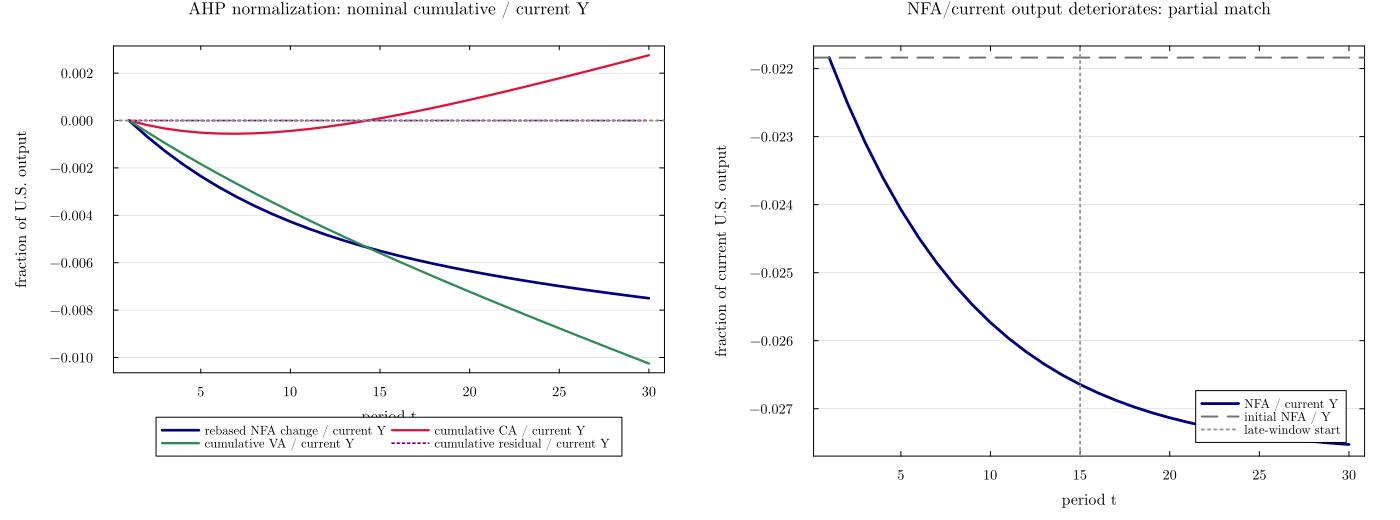

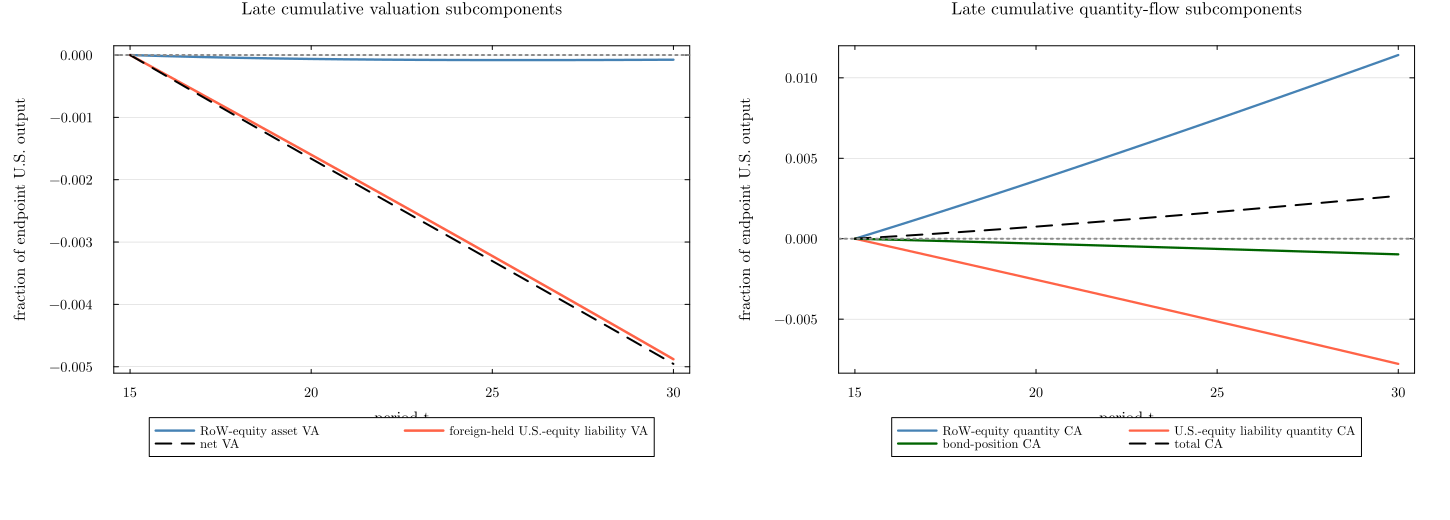

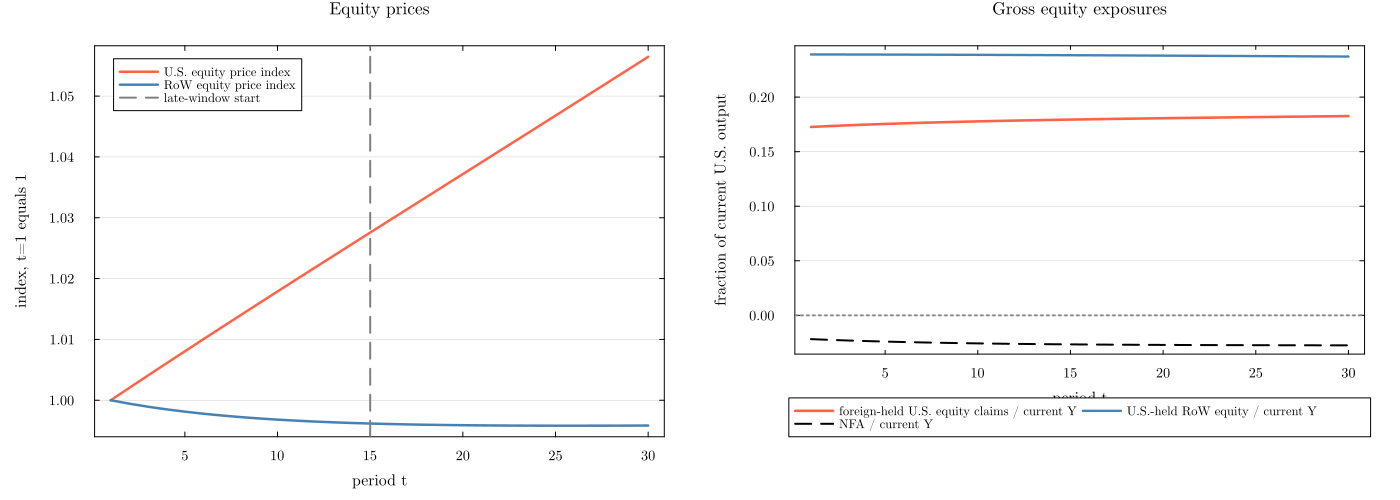

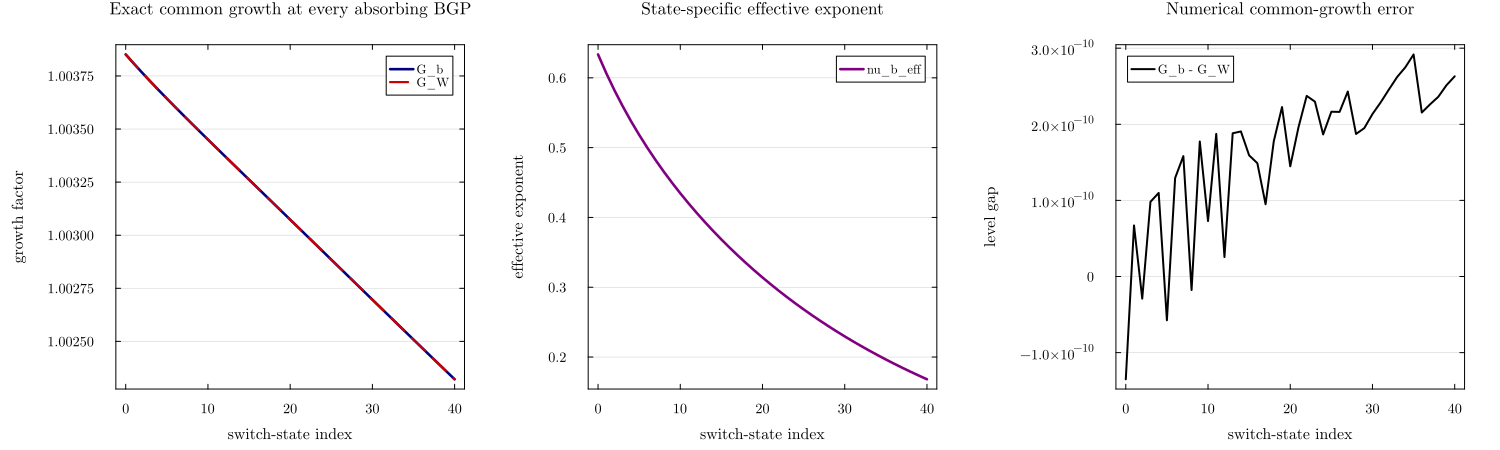


PNG exports complete:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_common_growth_search/best_ahp_two_panel.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_common_growth_search/best_va_ca_subcomponents.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_common_growth_search/best_prices_exposures.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_common_growth_search/best_common_growth_diagnostics.png


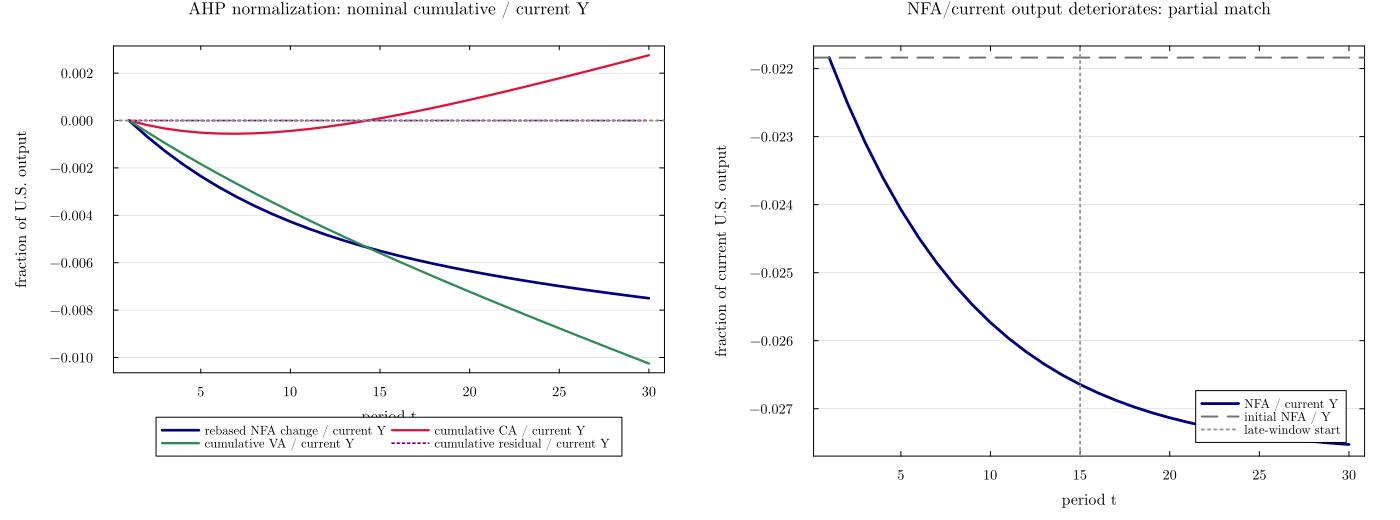

In [8]:
a = best_accounting
tt = collect(1:a.T)
Y = a.Y_US
Y_end = Y[end]
i0 = a.late_start
late_plot_range = i0:a.T

ahp_nfa_change_current_Y = (a.NFA .- a.NFA[1]) ./ Y
ahp_cum_CA_current_Y = a.cum_CA ./ Y
ahp_cum_VA_current_Y = a.cum_VA ./ Y
ahp_cum_RES_current_Y = a.cum_RES ./ Y

p_ahp = plot(tt, ahp_nfa_change_current_Y, color=:navy, lw=2.7,
             label="rebased NFA change / current Y",
             xlabel="period t", ylabel="fraction of U.S. output",
             title="AHP normalization: nominal cumulative / current Y",
             legend=:outerbottom, legend_columns=2)
plot!(p_ahp, tt, ahp_cum_CA_current_Y, color=:crimson, lw=2.3,
      label="cumulative CA / current Y")
plot!(p_ahp, tt, ahp_cum_VA_current_Y, color=:seagreen, lw=2.3,
      label="cumulative VA / current Y")
plot!(p_ahp, tt, ahp_cum_RES_current_Y, color=:purple, lw=1.7, ls=:dot,
      label="cumulative residual / current Y")
hline!(p_ahp, [0.0], color=:gray55, ls=:dot, label="")

nfa_ratio = a.NFA ./ Y
ratio_title = best_metrics.full_ratio_change < 0 ?
              "NFA/current output deteriorates: partial match" :
              "NFA/current output improves: mechanism near miss"
p_ratio = plot(tt, nfa_ratio, color=:navy, lw=2.8,
               label="NFA / current Y", xlabel="period t",
               ylabel="fraction of current U.S. output",
               title=ratio_title, legend=:bottomright)
hline!(p_ratio, [nfa_ratio[1]], color=:gray45, ls=:dash,
       label="initial NFA / Y")
vline!(p_ratio, [i0], color=:gray60, ls=:dot,
       label="late-window start")

fig_ahp_two_panel = plot(p_ahp, p_ratio, layout=(1, 2),
                         size=(1400, 520), margin=9mm)
ahp_png = joinpath(OUTDIR, "best_ahp_two_panel.png")
savefig(fig_ahp_two_panel, ahp_png)
display(fig_ahp_two_panel)

p_va = plot(late_plot_range,
            (a.late_cum_VA_asset ./ Y_end)[late_plot_range],
            color=:steelblue, lw=2.4, label="RoW-equity asset VA",
            xlabel="period t", ylabel="fraction of endpoint U.S. output",
            title="Late cumulative valuation subcomponents",
            legend=:outerbottom, legend_columns=2)
plot!(p_va, late_plot_range,
      (a.late_cum_VA_liability ./ Y_end)[late_plot_range],
      color=:tomato, lw=2.5, label="foreign-held U.S.-equity liability VA")
plot!(p_va, late_plot_range,
      (a.late_cum_VA ./ Y_end)[late_plot_range],
      color=:black, lw=2.0, ls=:dash, label="net VA")
hline!(p_va, [0.0], color=:gray55, ls=:dot, label="")

p_ca = plot(late_plot_range,
            (a.late_cum_CA_asset ./ Y_end)[late_plot_range],
            color=:steelblue, lw=2.3, label="RoW-equity quantity CA",
            xlabel="period t", ylabel="fraction of endpoint U.S. output",
            title="Late cumulative quantity-flow subcomponents",
            legend=:outerbottom, legend_columns=2)
plot!(p_ca, late_plot_range,
      (a.late_cum_CA_liability ./ Y_end)[late_plot_range],
      color=:tomato, lw=2.3, label="U.S.-equity liability quantity CA")
plot!(p_ca, late_plot_range,
      (a.late_cum_CA_bond ./ Y_end)[late_plot_range],
      color=:darkgreen, lw=2.3, label="bond-position CA")
plot!(p_ca, late_plot_range,
      (a.late_cum_CA ./ Y_end)[late_plot_range],
      color=:black, lw=2.0, ls=:dash, label="total CA")
hline!(p_ca, [0.0], color=:gray55, ls=:dot, label="")

fig_subcomponents = plot(p_va, p_ca, layout=(1, 2),
                         size=(1450, 520), margin=9mm)
subcomponents_png = joinpath(OUTDIR, "best_va_ca_subcomponents.png")
savefig(fig_subcomponents, subcomponents_png)
display(fig_subcomponents)

p_prices = plot(tt, a.q_US ./ a.q_US[1],
                color=:tomato, lw=2.5, label="U.S. equity price index",
                xlabel="period t", ylabel="index, t=1 equals 1",
                title="Equity prices", legend=:topleft)
plot!(p_prices, tt, a.q_W ./ a.q_W[1],
      color=:steelblue, lw=2.5, label="RoW equity price index")
vline!(p_prices, [i0], color=:gray50, ls=:dash,
       label="late-window start")

p_exposure = plot(tt, a.liability_position ./ Y,
                  color=:tomato, lw=2.6,
                  label="foreign-held U.S. equity claims / current Y",
                  xlabel="period t", ylabel="fraction of current U.S. output",
                  title="Gross equity exposures", legend=:outerbottom,
                  legend_columns=2)
plot!(p_exposure, tt, a.asset_position ./ Y,
      color=:steelblue, lw=2.4, label="U.S.-held RoW equity / current Y")
plot!(p_exposure, tt, a.NFA ./ Y,
      color=:black, lw=2.0, ls=:dash, label="NFA / current Y")
hline!(p_exposure, [0.0], color=:gray55, ls=:dot, label="")

fig_prices_exposures = plot(p_prices, p_exposure, layout=(1, 2),
                            size=(1400, 500), margin=9mm)
prices_png = joinpath(OUTDIR, "best_prices_exposures.png")
savefig(fig_prices_exposures, prices_png)
display(fig_prices_exposures)

switch_t = Float64[r["switch_index"] for r in best_common_diagnostics]
G_b = Float64[r["G_b"] for r in best_common_diagnostics]
G_W = Float64[r["G_W"] for r in best_common_diagnostics]
nu_eff = Float64[r["nu_b_eff"] for r in best_common_diagnostics]
gaps = Float64[r["level_gap"] for r in best_common_diagnostics]
p_growth = plot(switch_t, G_b, color=:navy, lw=2.6, label="G_b",
                xlabel="switch-state index", ylabel="growth factor",
                title="Exact common growth at every absorbing BGP")
plot!(p_growth, switch_t, G_W, color=:red3, ls=:dash, lw=2.2, label="G_W")
p_nu = plot(switch_t, nu_eff, color=:purple, lw=2.6, label="nu_b_eff",
            xlabel="switch-state index", ylabel="effective exponent",
            title="State-specific effective exponent")
p_gap = plot(switch_t, gaps, color=:black, lw=2.0, label="G_b - G_W",
             xlabel="switch-state index", ylabel="level gap",
             title="Numerical common-growth error")
p_cg = plot(p_growth, p_nu, p_gap, layout=(1, 3), size=(1500, 450))
common_growth_png = joinpath(OUTDIR, "best_common_growth_diagnostics.png")
savefig(p_cg, common_growth_png)
display(p_cg)

println("\nPNG exports complete:")
foreach(path -> println("  ", path),
        [ahp_png, subcomponents_png, prices_png, common_growth_png])

fig_ahp_two_panel


In [9]:
println("\n" * repeat("=", 86))
println("NOTEBOOK 15 PATHWISE COMMON-GROWTH CALIBRATION RESULT")
println(repeat("=", 86))
println("RoW-only failure confirmed:        ", strict_failure_confirmed)
println("Pathwise fallback activated:       true")
println("Selected calibration:              ", best.spec.label)
println("Classification:                    ", best_classification)
@printf("Global reference nu_b:             %.9f (seed %.3f)\n",
        best_result.params.ν_b, best.spec.ν_b_seed)
@printf("State-specific nu_b_eff range:     [%.9f, %.9f] (std %.3e)\n",
        best_validity.common.nu_b_eff_min, best_validity.common.nu_b_eff_max,
        best_validity.common.nu_b_eff_std)
@printf("Maximum pathwise level gap:        %.3e\n", best_validity.common.max_level_gap)
@printf("Maximum pathwise log gap:          %.3e\n", best_validity.common.max_log_gap)
@printf("Maximum extended-BGP residual:     %.3e\n", best_validity.common.max_extended_bgp_residual)
@printf("NFA/Y:                             %+.6f -> %+.6f (change %+.6f)\n",
        best_metrics.nfa_initial_current_Y, best_metrics.nfa_final_current_Y,
        best_metrics.full_ratio_change)
@printf("Whole-path nominal NFA move / Y_T: %+.6f\n", best_metrics.whole_path_nfa_move)
@printf("Late asset VA / Y_T:               %+.6f\n", best_metrics.late_va_asset)
@printf("Late liability VA / Y_T:           %+.6f\n", best_metrics.late_va_liability)
@printf("Late net VA / Y_T:                 %+.6f\n", best_metrics.late_va_net)
@printf("Late CA / Y_T:                     %+.6f\n", best_metrics.late_ca)
@printf("Foreign U.S.-equity exposure:      %.6f\n", best_metrics.late_foreign_exposure)
@printf("q_US and q_W growth:               %.6f, %.6f\n",
        best_metrics.q_US_growth, best_metrics.q_W_growth)
println("Matches desired negative NFA direction: ", best_matches_ahp_direction)

best_validity.valid || error("Selected result failed a hard model/common-growth gate.")
strict_failure_confirmed || error("Fallback sequencing invariant failed.")
best_validity.exact_common || error("Selected result misses exact pathwise common growth.")
best_validity.extended_bgp_valid || error("An extended-path BGP failed convergence or residual tolerance.")
best_validity.exponent_ordering || error("A state-specific effective exponent violates exponent ordering.")

println("\nInterpretation:")
if best_matches_ahp_direction
    println("  The selected calibration reproduces the desired NFA direction with liability-side")
    println("  price revaluation and relatively smooth CA. Common growth is exact at every")
    println("  absorbing switch-state BGP through the reported state-specific effective exponents.")
else
    println("  This is an explicitly labelled mechanism near miss, not a full AHP replication.")
    println("  Pathwise common growth is nevertheless exact; the remaining gap is economic,")
    println("  not a failure of the common-growth restriction.")
end
println("\nArtifacts written to: ", OUTDIR)
foreach(name -> println("  - ", name), sort(readdir(OUTDIR)))



NOTEBOOK 15 PATHWISE COMMON-GROWTH CALIBRATION RESULT
RoW-only failure confirmed:        true
Pathwise fallback activated:       true
Selected calibration:              cg_us_u_level_111
Classification:                    common_growth_liability_revaluation_partial_pattern
Global reference nu_b:             0.633519029 (seed 0.100)
State-specific nu_b_eff range:     [0.168174916, 0.633519029] (std 1.334e-01)
Maximum pathwise level gap:        2.917e-10
Maximum pathwise log gap:          2.910e-10
Maximum extended-BGP residual:     9.995e-10
NFA/Y:                             -0.021838 -> -0.027525 (change -0.005687)
Whole-path nominal NFA move / Y_T: -0.007500
Late asset VA / Y_T:               -0.000075
Late liability VA / Y_T:           -0.004880
Late net VA / Y_T:                 -0.004955
Late CA / Y_T:                     +0.002668
Foreign U.S.-equity exposure:      0.181239
q_US and q_W growth:               1.056461, 0.995842
Matches desired negative NFA direction: true

Interp

## Reading the selected calibration

The output should be interpreted in this order.

1. **Why the original cumulative CA/Y rises and falls.** The raw cumulative CA numerator in the Notebook-12 outputs is monotone. Its hump is created by dividing by rapidly growing current U.S. output (and similarly by current U.S. equity value in the `_e` figure). This is a moving-denominator effect, not a reversal of the cumulative nominal CA.

2. **Why the audited RoW-only restoration fails.** Lowering RoW growth enough to satisfy reference common growth with literal `ν_b=0.10` also suppresses RoW equity values, foreign portfolio scale, and the U.S. equity revaluation channel. Across the five audited `(ξ_W, a_W)` roots, NFA/Y improves and CA dominates; none passes the mechanism check. This confirms failure within the pre-registered family, not over every possible RoW calibration. `row_growth_recalibration_audit.csv` records the evidence.

3. **How pathwise common growth is restored.** Only after the bounded Stage-A assertion succeeds does the notebook activate `common_world_growth=true`. It calibrates a global `ν_b` at the reference BGP, while each absorbing switch-state BGP uses the Notebook-12 state-specific `ν_b_eff` needed for `G_N,US^ν_b_eff = G_N,W^ξ_W`. The effective-exponent range, per-state BGP convergence and residual, and maximum numerical growth gap are exported over the full reporting-plus-buffer path. Thus the other structural inputs remain time invariant, while the growth-selection exponent is explicitly state specific.

4. **What each adjustment does.** The reported effects are mechanism interpretations of a joint calibration, not separately identified causal estimates. Lower `β` and intermediate `κ` form the feasible financial block; high `ϑ_US` transmits U.S. growth into equity value; `ω̄_star` retains a large foreign liability exposure; and `(a_W, ξ_W)` keep `q_W` comparatively stable. The higher `ν_u` ceiling remains above every `ν_b_eff`. The 11% time-invariant increase in U.S. unbalanced-regime productivity levels is the decisive local change: it raises `q_US` relative to `q_W` and creates the liability price revaluation that makes NFA fall.

5. **What remains unmatched.** The result is a qualitative partial match, not the large empirical AHP magnitude: NFA/Y deteriorates and liability VA dominates smooth CA, but asset VA is economically flat and slightly negative. Pathwise common growth itself is exact up to numerical tolerance, so the remaining mismatch concerns the size and composition of the AHP effects rather than cross-country trend consistency.
